In [43]:
# Load libraries and data
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Set style for better-looking plots
plt.rcParams['figure.figsize'] = (12, 8)

# Load the merged data
data = pd.read_csv('../data/processed/processed_data.csv')
data.head(3)

,participant_id,condition,imageid,headline,before_AI_Real_Fake,confidence_rating_before_AI,with_AI_Real_Fake,confidence_rating_with_AI,final rating submitted,ground_truth_with_AI,after_AI_seen_before,after_AI_ground_truth,after_AI_Real_Fake,confidence_rating_after_AI,phase,week
0,560379c9e372c00011bd4a90,1,0,"Senator Christopher J. Dodd, with his wife and...",FAKE,100,FAKE,100,100.0,fake,No,fake,Fake,100,Phase1,0
1,560379c9e372c00011bd4a90,1,5,"Mikerlyne Dorvil, accused of causing the earth...",FAKE,100,FAKE,100,100.0,fake,No,fake,Fake,100,Phase1,0
2,560379c9e372c00011bd4a90,1,7,A crowd gathered on Tuesday in Minneapolis aft...,REAL,48,REAL,100,100.0,real,No,real,Real,80,Phase1,0


In [ ]:
# Process data for plotting

# Calculate accuracy for before, with, after AI
data['before_accuracy'] = (data['before_AI_Real_Fake'].str.lower() == data['ground_truth_with_AI'].str.lower()).astype(int) * data['confidence_rating_before_AI'] / 100
data['with_accuracy'] = (data['with_AI_Real_Fake'].str.lower() == data['ground_truth_with_AI'].str.lower()).astype(int) * data['confidence_rating_with_AI'] / 100
data['after_accuracy'] = (data['after_AI_Real_Fake'].str.lower() == data['after_AI_ground_truth'].str.lower()).astype(int) * data['confidence_rating_after_AI'] / 100

# Numeric belief for before, with, after AI (Fake 0, Real 1)
data['before_belief'] = (data['before_AI_Real_Fake'].str.lower() == 'real').astype(int)
data['with_belief'] = (data['with_AI_Real_Fake'].str.lower() == 'real').astype(int)
data['after_belief'] = (data['after_AI_Real_Fake'].str.lower() == 'real').astype(int)

# Reshape data for plotting
plot_data = []
for idx, row in data.iterrows():
    for time_point, acc_col, belief_col, gt_col in [('before', 'before_accuracy', 'before_belief', 'ground_truth_with_AI'), ('with', 'with_accuracy', 'with_belief', 'ground_truth_with_AI'), ('after', 'after_accuracy', 'after_belief', 'after_AI_ground_truth')]:
        plot_data.append({
            'participant_id': row['participant_id'], 'condition': row['condition'], 'week': row['week'], 'imageid': row['imageid'],
            'time_point': time_point, 'accuracy': row[acc_col], 'belief': row[belief_col], 'phase': row['phase'], 'ground_truth': row[gt_col].lower()
        })
plot_df = pd.DataFrame(plot_data)

plot_df.head(3)



KeyError: 'itemid'

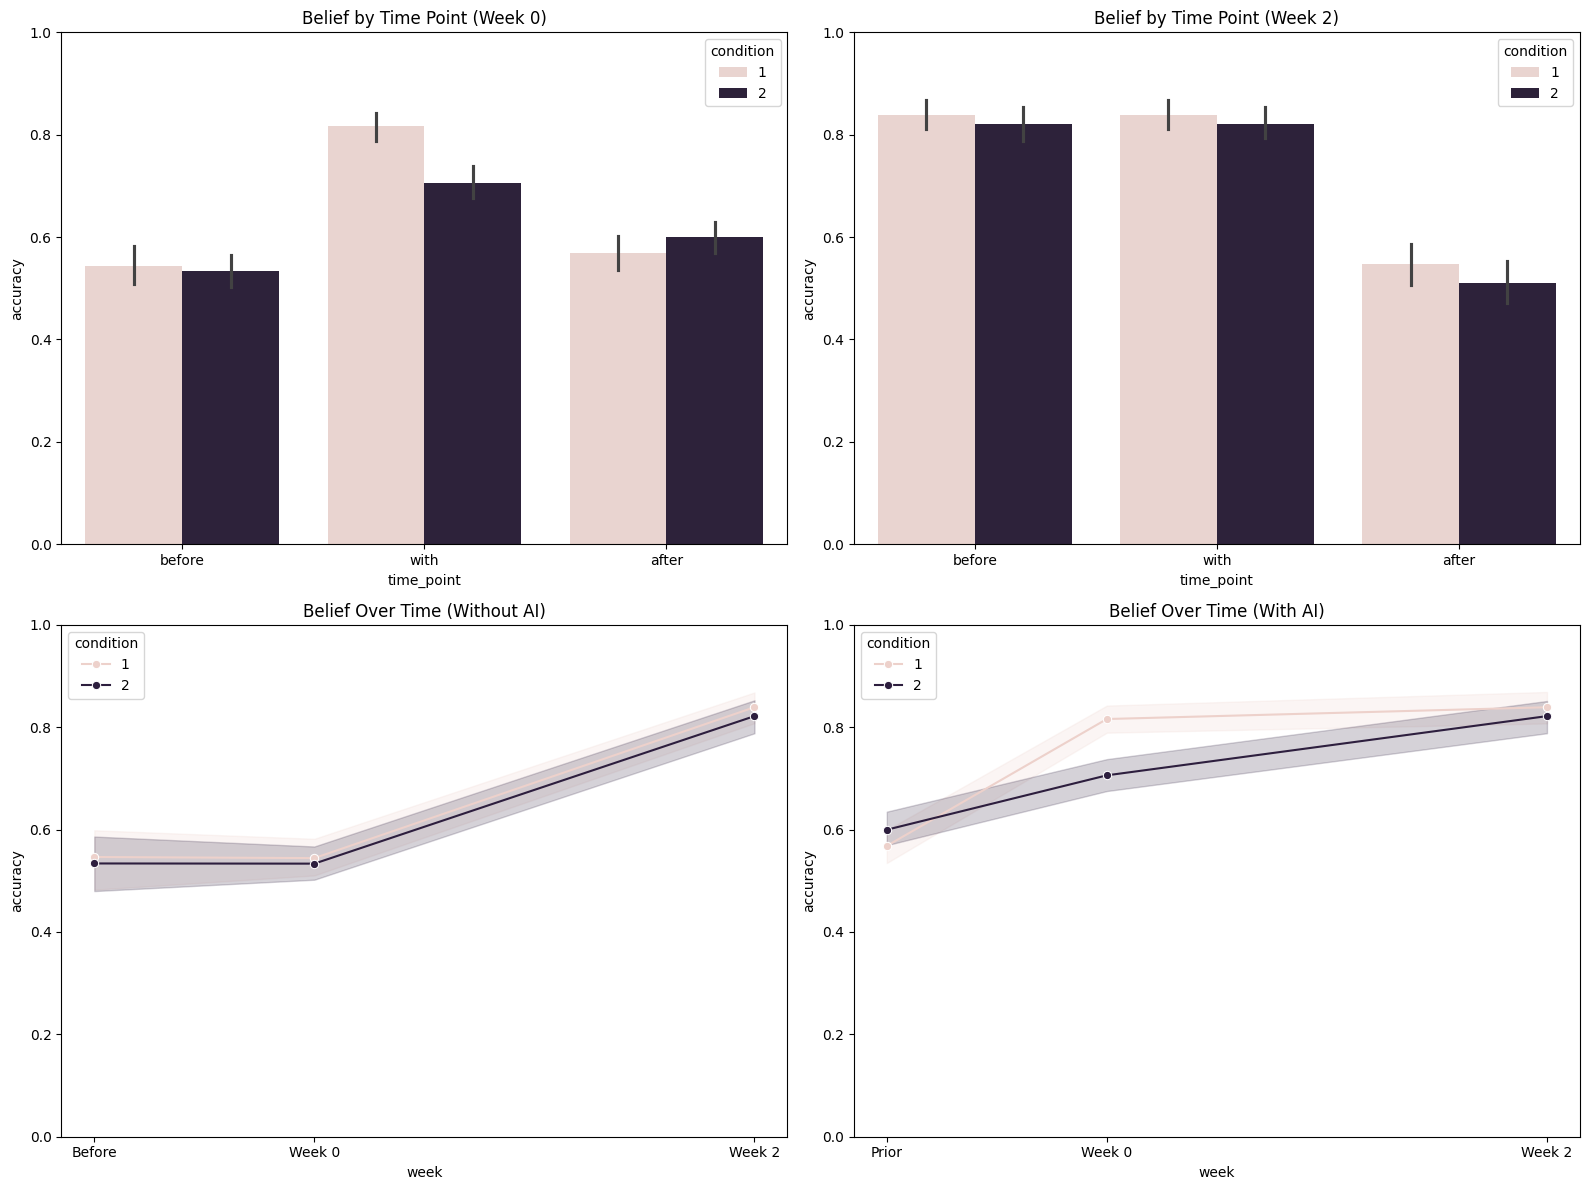

In [46]:
# Create plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# set ylimits for all plots
for ax in axes.flatten(): ax.set_ylim(0, 1)

# 1. Week 0 barchart
sns.barplot(data=plot_df[plot_df['week'] == 0], x='time_point', y='accuracy', hue='condition', ax=axes[0,0])
axes[0,0].set_title('Belief by Time Point (Week 0)')

# 2. Week 2 barchart
sns.barplot(data=plot_df[plot_df['week'] == 2], x='time_point', y='accuracy', hue='condition', ax=axes[0,1])
axes[0,1].set_title('Belief by Time Point (Week 2)')

# 3. Line plot: without AI conditions (before from Phase1, Week 0&2 without AI)
no_ai_data = pd.concat([
    data[data['phase'] == 'Phase1'][['participant_id', 'condition', 'after_accuracy']].assign(week=-1, belief=lambda x: x['after_accuracy']),
    plot_df[(plot_df['time_point'] == 'before') & (plot_df['week'].isin([0,2]))][['participant_id', 'condition', 'week', 'accuracy']]
])
sns.lineplot(data=no_ai_data, x='week', y='accuracy', hue='condition', marker='o', ax=axes[1,0])
axes[1,0].set_title('Belief Over Time (Without AI)')
axes[1,0].set_xticks([-1, 0, 2])
axes[1,0].set_xticklabels(['Before', 'Week 0', 'Week 2'])

# 4. Line plot: with AI conditions (prior, Week 0&2 with AI)
with_ai_data = pd.concat([
    data[data['phase'] == 'Phase1'][['participant_id', 'condition', 'after_accuracy']].assign(week=-1, accuracy=lambda x: x['after_accuracy']),
    plot_df[(plot_df['time_point'] == 'with') & (plot_df['week'].isin([0,2]))][['participant_id', 'condition', 'week', 'accuracy']]
])
sns.lineplot(data=with_ai_data, x='week', y='accuracy', hue='condition', marker='o', ax=axes[1,1])
axes[1,1].set_title('Belief Over Time (With AI)')
axes[1,1].set_xticks([-1, 0, 2])
axes[1,1].set_xticklabels(['Prior', 'Week 0', 'Week 2'])

plt.tight_layout()
plt.show()

Ground truth: fake


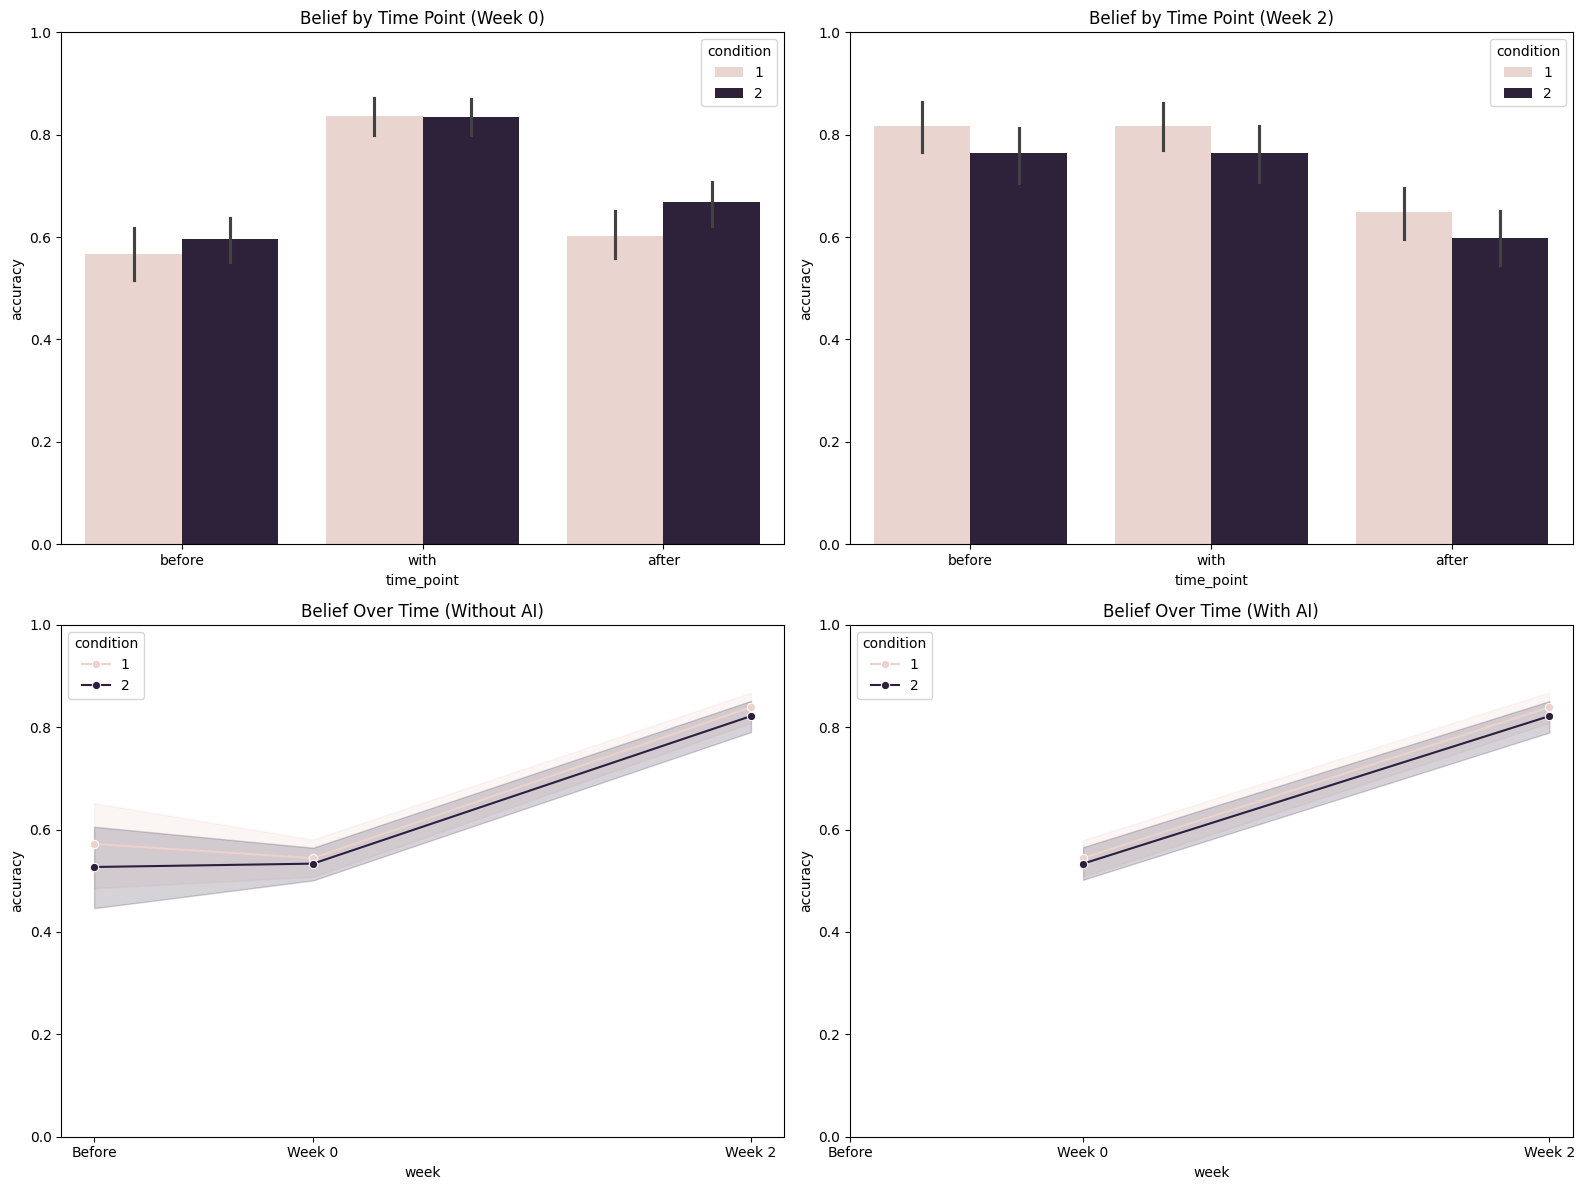

Ground truth: real


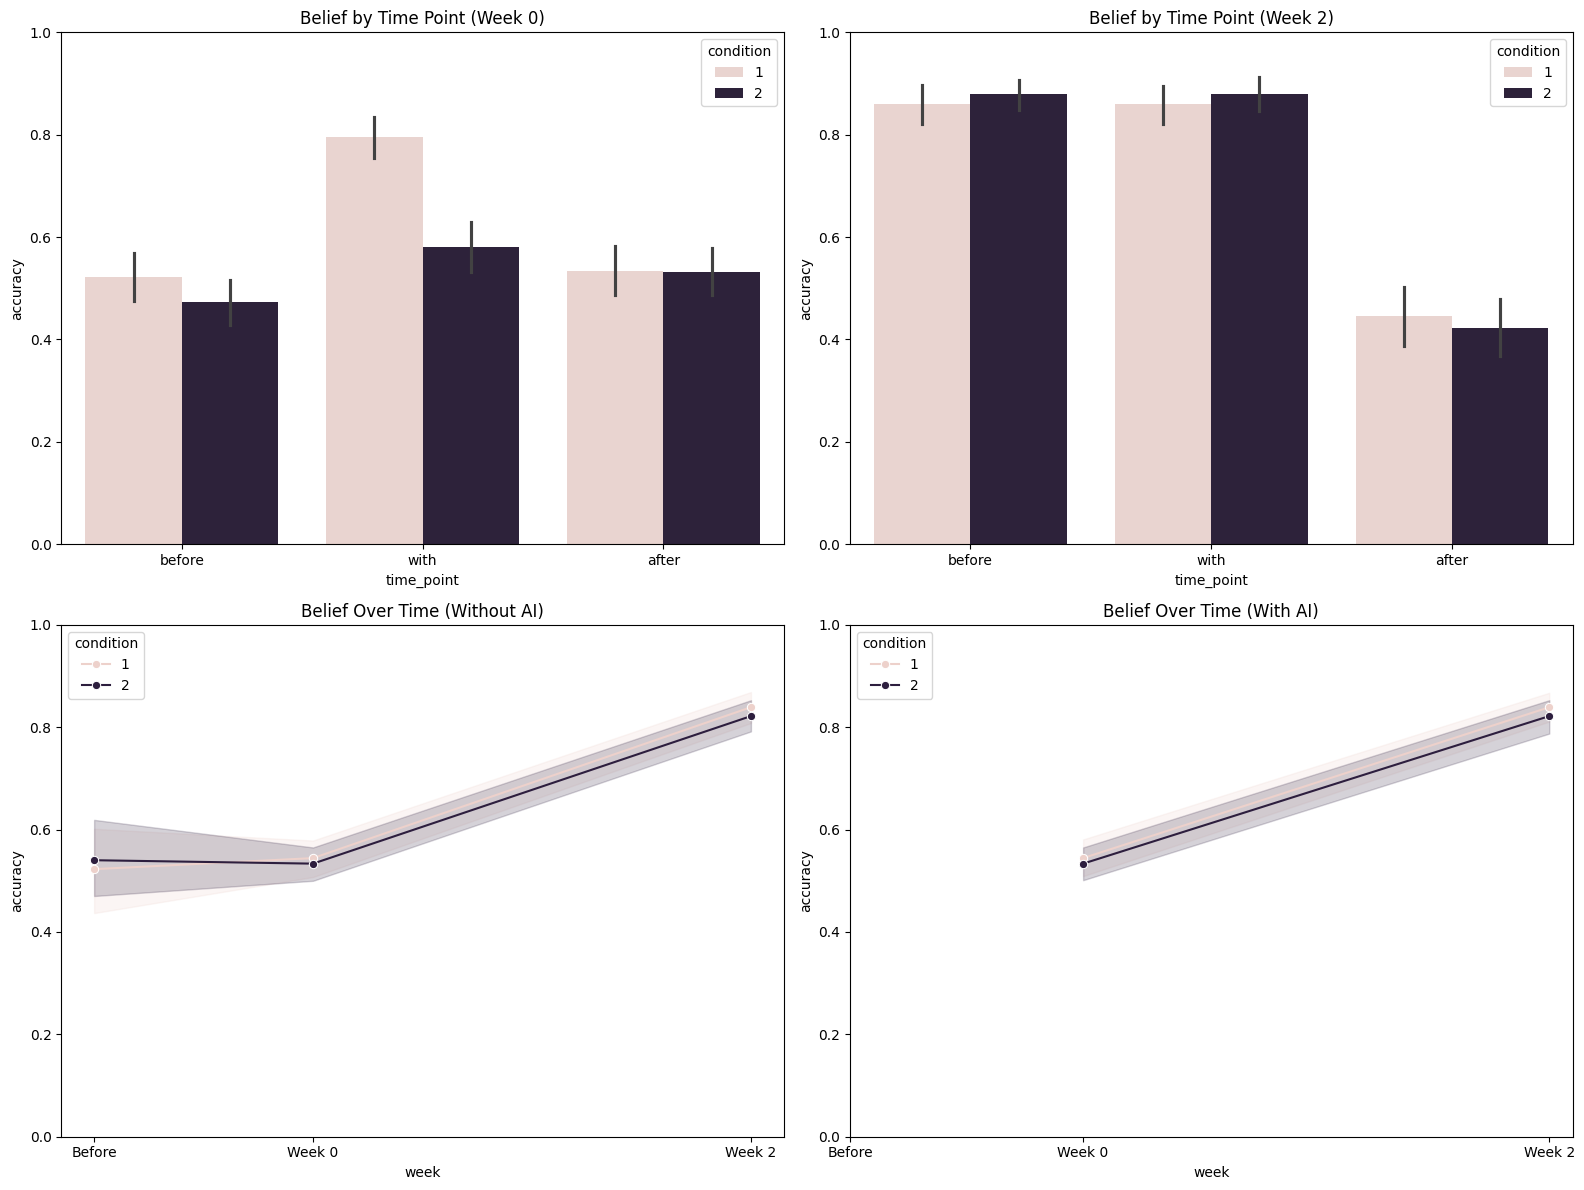

In [47]:

for ground_truth in ['fake', 'real']:
    # Create plots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # set ylimits for all plots
    for ax in axes.flatten(): ax.set_ylim(0, 1)

    print(f"Ground truth: {ground_truth}")

    # 1. Week 0 barchart
    sns.barplot(data=plot_df[(plot_df['week'] == 0) & (plot_df["ground_truth"]==ground_truth)], x='time_point', y='accuracy', hue='condition', ax=axes[0,0])
    axes[0,0].set_title('Belief by Time Point (Week 0)')

    # 2. Week 2 barchart
    sns.barplot(data=plot_df[(plot_df['week'] == 2) & (plot_df["ground_truth"]==ground_truth)], x='time_point', y='accuracy', hue='condition', ax=axes[0,1])
    axes[0,1].set_title('Belief by Time Point (Week 2)')

    # 3. Line plot: without AI conditions (before from Phase1, Week 0&2 without AI)
    no_ai_data = pd.concat([
        data[(data.phase == 'Phase1') & (data.after_AI_ground_truth == ground_truth)][['participant_id', 'condition', 'after_accuracy']].assign(week=-1, belief=lambda x: x['after_accuracy']),
        plot_df[(plot_df['time_point'] == 'before') & (plot_df['week'].isin([0,2]))][['participant_id', 'condition', 'week', 'accuracy']]
    ])
    sns.lineplot(data=no_ai_data, x='week', y='accuracy', hue='condition', marker='o', ax=axes[1,0])
    axes[1,0].set_title('Belief Over Time (Without AI)')
    axes[1,0].set_xticks([-1, 0, 2])
    axes[1,0].set_xticklabels(['Before', 'Week 0', 'Week 2'])

    # 4. Line plot: with AI conditions (prior, Week 0&2 with AI)
    with_ai_data = pd.concat([
        data[(data.phase == 'Phase2') & (data.ground_truth_with_AI == ground_truth)][['participant_id', 'condition', 'with_accuracy']].assign(week=-1, accuracy=lambda x: x['with_accuracy']),
        plot_df[(plot_df['time_point'] == 'before') & (plot_df['week'].isin([0,2]))][['participant_id', 'condition', 'week', 'accuracy']]
    ])
    sns.lineplot(data=with_ai_data, x='week', y='accuracy', hue='condition', marker='o', ax=axes[1,1])
    axes[1,1].set_title('Belief Over Time (With AI)')
    axes[1,1].set_xticks([-1, 0, 2])
    axes[1,1].set_xticklabels(['Before', 'Week 0', 'Week 2'])

    plt.tight_layout()
    plt.show()